# 4) Forecast New York wind speed using LSTMs and Keras Library

In [156]:
# biblioteca
import numpy as np 
import pandas as pd 
 
import matplotlib.pyplot as plt 

In [157]:

# base para o modelo lstm 
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras import metrics
# normalizar os dados
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
 

In [158]:
df = pd.read_csv('NYW.csv')
df.head()

,USW00014732,"LA GUARDIA AIRPORT, NY US",7/1/2017,9.84
0,USW00014732,"LA GUARDIA AIRPORT, NY US",7/2/2017,8.72
1,USW00014732,"LA GUARDIA AIRPORT, NY US",7/3/2017,7.83
2,USW00014732,"LA GUARDIA AIRPORT, NY US",7/4/2017,4.92
3,USW00014732,"LA GUARDIA AIRPORT, NY US",7/5/2017,9.62
4,USW00014732,"LA GUARDIA AIRPORT, NY US",7/6/2017,8.05


In [159]:
df = pd.read_csv('NYW.csv', header=None)
df.head()

,0,1,2,3
0,USW00014732,"LA GUARDIA AIRPORT, NY US",7/1/2017,9.84
1,USW00014732,"LA GUARDIA AIRPORT, NY US",7/2/2017,8.72
2,USW00014732,"LA GUARDIA AIRPORT, NY US",7/3/2017,7.83
3,USW00014732,"LA GUARDIA AIRPORT, NY US",7/4/2017,4.92
4,USW00014732,"LA GUARDIA AIRPORT, NY US",7/5/2017,9.62


In [160]:
L = len(df)
print(L)

732


In [161]:
Y = np.array([df.iloc[:,3]]) # velocidade do vento

In [162]:
print(Y[0][:5])

[9.84 8.72 7.83 4.92 9.62]


In [163]:
Y.shape

(1, 732)

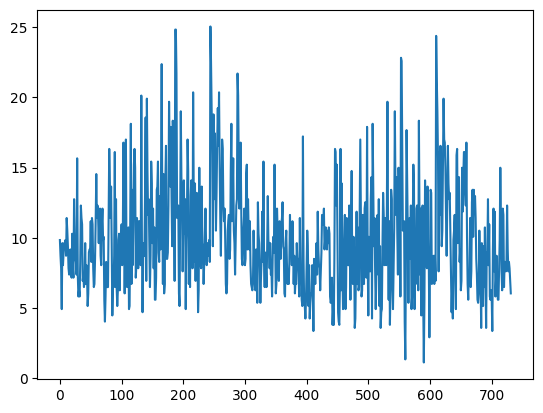

In [164]:
plt.plot(Y[0,:])
plt.show(block=False)

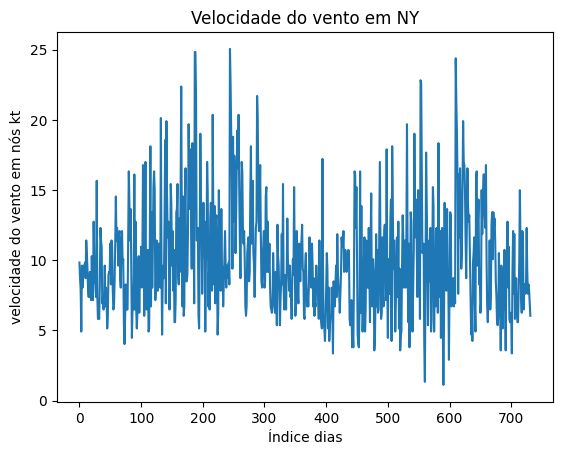

In [165]:
plt.plot(Y[0,:])
#plt.legend()                        
plt.title('Velocidade do vento em NY')
plt.xlabel('Índice dias')
plt.ylabel('velocidade do vento em nós kt')
plt.show()

In [166]:
X1 = Y[:,0:L-5]
X2 = Y[:,1:L-4]
X3 = Y[:,2:L-3]
 

In [167]:
X1

array([[ 9.84,  8.72,  7.83,  4.92,  9.62,  8.05,  8.95,  9.62,  9.4 ,
         9.84,  8.72, 11.41, 10.51,  9.4 ,  7.83,  7.38,  8.5 ,  9.17,
         7.38,  7.16, 10.29,  7.83,  7.16, 12.75, 10.07,  8.5 ,  8.28,
         7.38, 15.66,  7.38,  5.82,  6.26,  5.82,  8.28, 12.3 , 11.41,
        10.96,  6.93,  7.38,  6.49,  6.93,  9.62,  6.71,  8.05,  7.38,
         5.14,  6.04,  8.95,  9.17,  9.17, 11.18,  8.28, 11.41, 10.96,
         7.83,  6.49,  6.71,  8.5 , 11.18, 14.54, 11.41, 12.3 , 11.41,
         9.62, 11.86, 12.08,  8.72,  8.05, 10.96, 12.08,  9.84, 10.07,
         5.59,  4.03,  5.82,  8.28,  6.49,  6.49,  6.49, 11.41, 16.33,
        14.09, 11.41, 13.65,  9.62,  4.47,  6.49,  6.49,  8.72, 16.11,
         6.49, 12.75,  6.49,  5.14,  6.26,  9.84, 10.29,  6.26,  9.62,
         9.17, 10.96,  8.05, 10.07, 16.78, 11.41,  6.04, 10.07, 17.  ,
         8.28,  6.49,  9.84, 10.74,  4.92,  5.14, 10.96, 18.12,  6.71,
        13.42,  8.05, 10.96, 15.21, 16.33, 14.99,  7.16,  8.05, 11.41,
      

In [168]:
X1.shape,X2.shape,X3.shape

((1, 727), (1, 727), (1, 727))

In [169]:
X2

array([[ 8.72,  7.83,  4.92,  9.62,  8.05,  8.95,  9.62,  9.4 ,  9.84,
         8.72, 11.41, 10.51,  9.4 ,  7.83,  7.38,  8.5 ,  9.17,  7.38,
         7.16, 10.29,  7.83,  7.16, 12.75, 10.07,  8.5 ,  8.28,  7.38,
        15.66,  7.38,  5.82,  6.26,  5.82,  8.28, 12.3 , 11.41, 10.96,
         6.93,  7.38,  6.49,  6.93,  9.62,  6.71,  8.05,  7.38,  5.14,
         6.04,  8.95,  9.17,  9.17, 11.18,  8.28, 11.41, 10.96,  7.83,
         6.49,  6.71,  8.5 , 11.18, 14.54, 11.41, 12.3 , 11.41,  9.62,
        11.86, 12.08,  8.72,  8.05, 10.96, 12.08,  9.84, 10.07,  5.59,
         4.03,  5.82,  8.28,  6.49,  6.49,  6.49, 11.41, 16.33, 14.09,
        11.41, 13.65,  9.62,  4.47,  6.49,  6.49,  8.72, 16.11,  6.49,
        12.75,  6.49,  5.14,  6.26,  9.84, 10.29,  6.26,  9.62,  9.17,
        10.96,  8.05, 10.07, 16.78, 11.41,  6.04, 10.07, 17.  ,  8.28,
         6.49,  9.84, 10.74,  4.92,  5.14, 10.96, 18.12,  6.71, 13.42,
         8.05, 10.96, 15.21, 16.33, 14.99,  7.16,  8.05, 11.41,  9.84,
      




X1, X2 e X3 são versões defasadas (ou atrasadas no tempo) da série temporal Y.

Essa é uma técnica muito comum em análise de séries temporais para transformar um problema em um formato que um modelo de Machine Learning, como o LSTM.


X1 = Y[:,0:L-5]

Cria X1, que contém a série Y do início (0) até o penúltimo ponto.

X2 = Y[:,1:L-4]

Cria X2, que é a mesma série Y, mas deslocada um passo no tempo. Ele começa no segundo ponto (1) e vai até o penúltimo ponto.

X3 = Y[:,2:L-3]

Cria X3, que é a série Y deslocada dois passos no tempo. Ele começa no terceiro ponto (2) e vai até o penúltimo ponto.

In [170]:
# Entrada para o modelo (passos de tempo): [X1, X2, X3]

X = np.concatenate([X1,X2,X3],axis=0) #  concatenar por linha =0, se fosse por coluna seria y
print(X.shape)
X = np.transpose(X)
print(X)
print(X.shape)


(3, 727)
[[ 9.84  8.72  7.83]
 [ 8.72  7.83  4.92]
 [ 7.83  4.92  9.62]
 ...
 [ 8.28 12.3   9.17]
 [12.3   9.17  7.61]
 [ 9.17  7.61  8.28]]
(727, 3)


X = np.transpose(X)

np.transpose(): Esta função inverte os eixos do array. O que era uma linha vira uma coluna, e vice-versa.

Resultado: O array X que tinha a forma (3, N) será transformado em um novo array com a forma (N, 3).

In [171]:
Y = np.transpose(Y[:,3:L-2])


In [172]:
print(Y[:20])

[[ 4.92]
 [ 9.62]
 [ 8.05]
 [ 8.95]
 [ 9.62]
 [ 9.4 ]
 [ 9.84]
 [ 8.72]
 [11.41]
 [10.51]
 [ 9.4 ]
 [ 7.83]
 [ 7.38]
 [ 8.5 ]
 [ 9.17]
 [ 7.38]
 [ 7.16]
 [10.29]
 [ 7.83]
 [ 7.16]]


In [173]:
sc= MinMaxScaler()
sc.fit(X)
print(sc)
sc.get_params()

MinMaxScaler()


{'clip': False, 'copy': True, 'feature_range': (0, 1)}

In [174]:
X= sc.transform(X) # padroniza os dados com valores de -1 à +1.
print(X)

[[0.36439616 0.31759298 0.28040117]
 [0.31759298 0.28040117 0.15879649]
 [0.28040117 0.15879649 0.35520267]
 ...
 [0.29920602 0.46719599 0.33639783]
 [0.46719599 0.33639783 0.27120769]
 [0.33639783 0.27120769 0.29920602]]


In [175]:
sc1 = MinMaxScaler() # padronizar ou normalizar os dados
sc1.fit(Y)
# padroniza os dados com valores de -1 à +1.
Y= sc1.transform(Y)


In [176]:
print(Y[:7])

[[0.15879649]
 [0.35520267]
 [0.28959465]
 [0.32720435]
 [0.35520267]
 [0.34600919]
 [0.36439616]]


In [177]:
# input em 3 dimensões no LSTM Neural Network

In [178]:
X.shape

(727, 3)

In [179]:
X = np.reshape(X,(X.shape[0],1,X.shape[1]))
X.shape

(727, 1, 3)

In [180]:
X[:10]

array([[[0.36439616, 0.31759298, 0.28040117]],

       [[0.31759298, 0.28040117, 0.15879649]],

       [[0.28040117, 0.15879649, 0.35520267]],

       [[0.15879649, 0.35520267, 0.28959465]],

       [[0.35520267, 0.28959465, 0.32720435]],

       [[0.28959465, 0.32720435, 0.35520267]],

       [[0.32720435, 0.35520267, 0.34600919]],

       [[0.35520267, 0.34600919, 0.36439616]],

       [[0.34600919, 0.36439616, 0.31759298]],

       [[0.36439616, 0.31759298, 0.43000418]]])

In [181]:
# separar treino de teste, teste com 20% dos dados, 80 para treino
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

In [182]:
# Cria um modelo sequencial no Keras, que permite empilhar camadas uma após a outra.

model= Sequential()

In [183]:

 
model.add(LSTM(5,activation='tanh',input_shape=(1,3),recurrent_activation='hard_sigmoid'))


#Adiciona uma camada LSTM (rede recorrente com memória) com:

#5 neurônios (células de memória),

#Função de ativação principal: tanh (usada para saída da célula),

#input_shape=(1, 3) → cada amostra tem 1 passo de tempo e 3 variáveis (features),

#recurrent_activation='hard_sigmoid' → função usada internamente nos portões da LSTM para decidir o que esquecer, guardar ou liberar.


/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [184]:
#Adiciona uma camada densa (fully connected) com 1 neurônio para gerar a saída final — útil para previsão de um único valor contínuo.

model.add(Dense(1))
 

In [185]:
model.compile(loss='mean_squared_error',optimizer='rmsprop',metrics=['mae'])
#Configura o modelo:

#loss: mean_squared_error (erro quadrático médio),

#optimizer: rmsprop (otimizador que ajusta a taxa de aprendizado de forma adaptativa),

#metrics: mae (erro absoluto médio, usada apenas para acompanhamento).


In [186]:


model.fit(X_train,Y_train,epochs= 10,verbose=2)
 
#Treina o modelo com:

#X_train e Y_train como dados de treino,

#epochs=10 → o modelo verá todo o dataset 10 vezes,

#verbose=2 → exibe logs resumidos do progresso de treino. 
 

Epoch 1/10
19/19 - 1s - 35ms/step - loss: 0.1256 - mae: 0.3190
Epoch 2/10
19/19 - 0s - 3ms/step - loss: 0.0839 - mae: 0.2475
Epoch 3/10
19/19 - 0s - 3ms/step - loss: 0.0566 - mae: 0.1902
Epoch 4/10
19/19 - 0s - 3ms/step - loss: 0.0375 - mae: 0.1461
Epoch 5/10
19/19 - 0s - 3ms/step - loss: 0.0268 - mae: 0.1224
Epoch 6/10
19/19 - 0s - 4ms/step - loss: 0.0229 - mae: 0.1150
Epoch 7/10
19/19 - 0s - 3ms/step - loss: 0.0220 - mae: 0.1150
Epoch 8/10
19/19 - 0s - 2ms/step - loss: 0.0219 - mae: 0.1151
Epoch 9/10
19/19 - 0s - 2ms/step - loss: 0.0218 - mae: 0.1147
Epoch 10/10
19/19 - 0s - 2ms/step - loss: 0.0216 - mae: 0.1149


No treino de redes neurais, época (ou epoch) é uma passada completa de todo o conjunto de treino pelo modelo.

- exemplo:

Você tem 100 amostras no X_train.

O modelo vai processar todas essas 100 amostras uma vez → isso é 1 época.

Na próxima época, ele repete o processo, mas agora com pesos um pouco ajustados pela época anterior.

- Por que usar várias épocas:

Porque o modelo não aprende tudo de uma vez. Cada época faz ajustes pequenos nos pesos para diminuir o erro. Com várias épocas, ele refina as previsões até convergir (ou até começar a overfitar).

- Observação:

Mais épocas ≠ melhor sempre.

Poucas épocas → modelo não aprende o suficiente (underfitting).

Muitas épocas → modelo memoriza demais e perde capacidade de generalizar (overfitting).


In [187]:
predict= model.predict(X_test)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


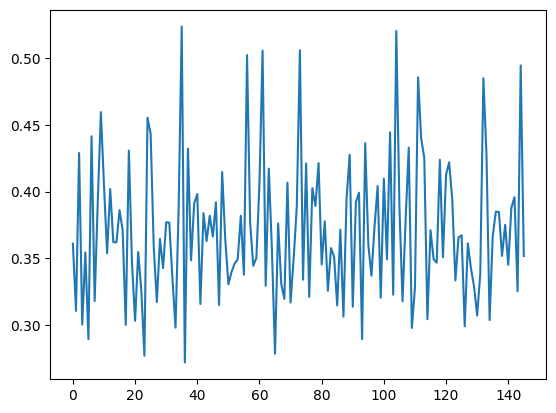

In [189]:
plt.plot(predict)

In [191]:
model= Sequential()
 
model.add(LSTM(10,activation='tanh',input_shape=(1,3),recurrent_activation='hard_sigmoid'))
 
model.add(Dense(1))
 
model.compile(loss='mean_squared_error',optimizer='rmsprop',metrics=['mae'])
 
model.fit(X_train,Y_train,epochs= 25,verbose=2)
 
predict= model.predict(X_test)

Epoch 1/25
19/19 - 1s - 32ms/step - loss: 0.1472 - mae: 0.3511
Epoch 2/25
19/19 - 0s - 2ms/step - loss: 0.1061 - mae: 0.2878
Epoch 3/25
19/19 - 0s - 2ms/step - loss: 0.0767 - mae: 0.2340
Epoch 4/25
19/19 - 0s - 2ms/step - loss: 0.0529 - mae: 0.1832
Epoch 5/25
19/19 - 0s - 2ms/step - loss: 0.0358 - mae: 0.1423
Epoch 6/25
19/19 - 0s - 2ms/step - loss: 0.0258 - mae: 0.1202
Epoch 7/25
19/19 - 0s - 3ms/step - loss: 0.0217 - mae: 0.1128
Epoch 8/25
19/19 - 0s - 3ms/step - loss: 0.0211 - mae: 0.1132
Epoch 9/25
19/19 - 0s - 2ms/step - loss: 0.0210 - mae: 0.1136
Epoch 10/25
19/19 - 0s - 3ms/step - loss: 0.0209 - mae: 0.1131
Epoch 11/25
19/19 - 0s - 3ms/step - loss: 0.0209 - mae: 0.1131
Epoch 12/25
19/19 - 0s - 3ms/step - loss: 0.0208 - mae: 0.1128
Epoch 13/25
19/19 - 0s - 3ms/step - loss: 0.0208 - mae: 0.1137
Epoch 14/25
19/19 - 0s - 3ms/step - loss: 0.0208 - mae: 0.1130
Epoch 15/25
19/19 - 0s - 4ms/step - loss: 0.0207 - mae: 0.1130
Epoch 16/25
19/19 - 0s - 2ms/step - loss: 0.0206 - mae: 0.1131


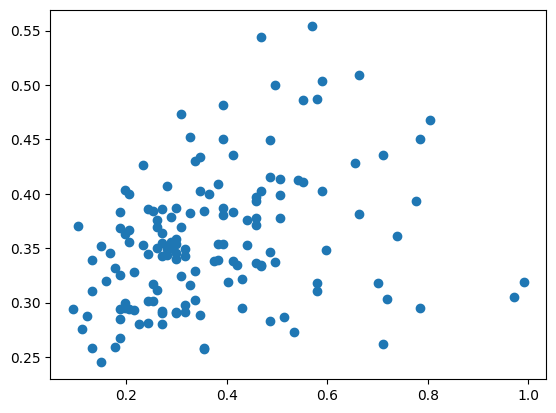

In [192]:
plt.figure(2)
plt.scatter(Y_test,predict)
plt.show(block=False)

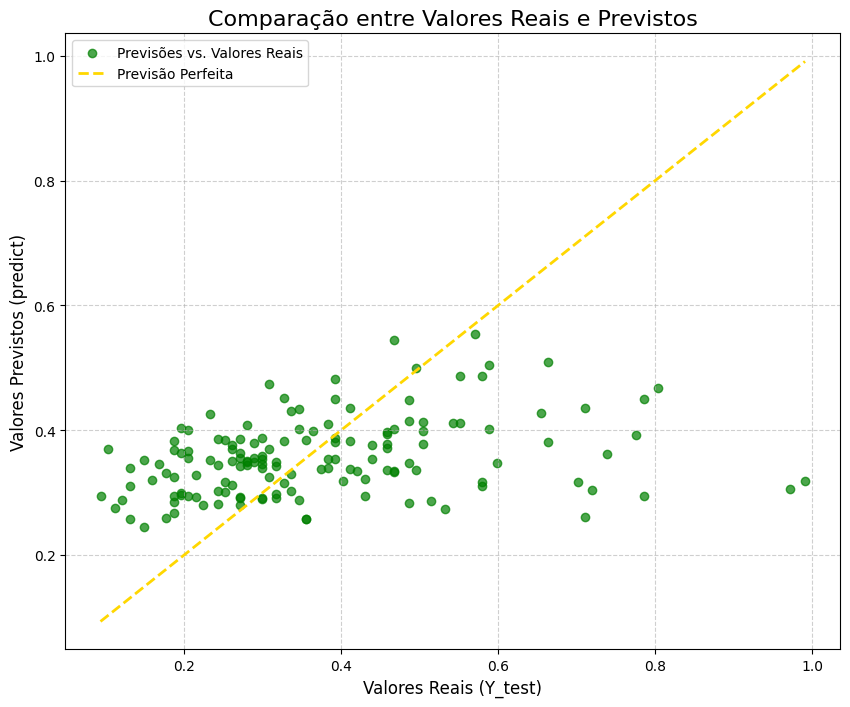

In [193]:
# Cria a figura com um tamanho maior para melhor visualização
plt.figure(figsize=(10, 8))

# Plota os pontos de teste com a cor 'verde'
# Cada ponto representa um par de (Y_test[i], predict[i])
plt.scatter(Y_test, predict, color='green', alpha=0.7, label='Previsões vs. Valores Reais')

# Adiciona a linha de previsão perfeita (Y=X) na cor 'amarelo'
# Esta linha é o que o seu modelo deveria prever se fosse perfeito
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],
         color='gold', linestyle='--', linewidth=2, label='Previsão Perfeita')

# Adiciona títulos e rótulos
plt.title('Comparação entre Valores Reais e Previstos', fontsize=16)
plt.xlabel('Valores Reais (Y_test)', fontsize=12)
plt.ylabel('Valores Previstos (predict)', fontsize=12)

# Adiciona a legenda e uma grade
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [194]:
# não há a mesma acurácia que o da temperatura

/tmp/ipykernel_15514/2482962164.py:4: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Predict,Real],["Predicted Data","Real Data"])


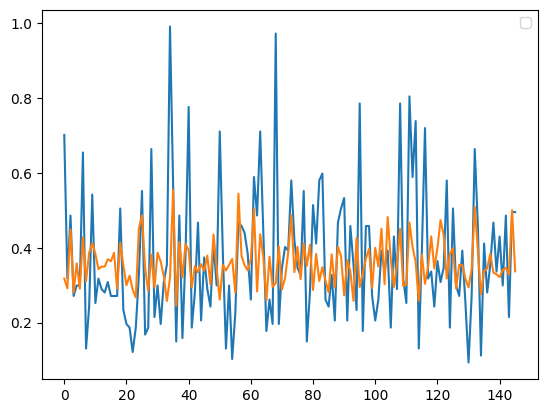

In [195]:
plt.figure(3)
Real=plt.plot(Y_test)
Predict = plt.plot(predict)
plt.legend([Predict,Real],["Predicted Data","Real Data"])
plt.show()

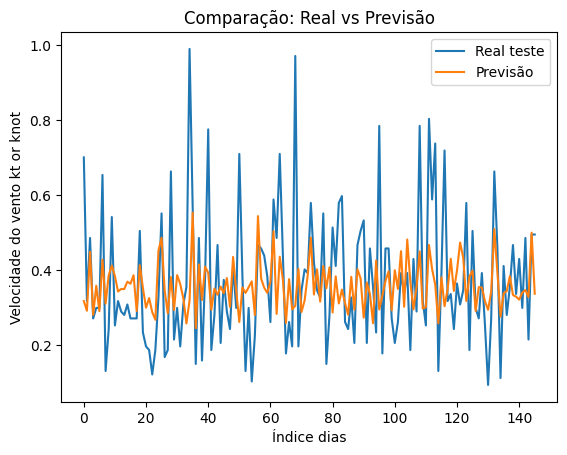

In [197]:
plt.figure(10)
plt.plot(Y_test, label='Real teste')      
plt.plot(predict, label='Previsão')   
plt.legend()                        
plt.title('Comparação: Real vs Previsão')
plt.xlabel('Índice dias')
plt.ylabel('Velocidade do vento kt or knot')
plt.show()



Epoch 1/50
19/19 - 1s - 33ms/step - loss: 0.1290 - mae: 0.3207
Epoch 2/50
19/19 - 0s - 2ms/step - loss: 0.0788 - mae: 0.2345
Epoch 3/50
19/19 - 0s - 2ms/step - loss: 0.0471 - mae: 0.1672
Epoch 4/50
19/19 - 0s - 2ms/step - loss: 0.0301 - mae: 0.1293
Epoch 5/50
19/19 - 0s - 3ms/step - loss: 0.0240 - mae: 0.1180
Epoch 6/50
19/19 - 0s - 2ms/step - loss: 0.0231 - mae: 0.1174
Epoch 7/50
19/19 - 0s - 2ms/step - loss: 0.0229 - mae: 0.1171
Epoch 8/50
19/19 - 0s - 2ms/step - loss: 0.0226 - mae: 0.1165
Epoch 9/50
19/19 - 0s - 2ms/step - loss: 0.0222 - mae: 0.1165
Epoch 10/50
19/19 - 0s - 3ms/step - loss: 0.0221 - mae: 0.1151
Epoch 11/50
19/19 - 0s - 4ms/step - loss: 0.0218 - mae: 0.1159
Epoch 12/50
19/19 - 0s - 3ms/step - loss: 0.0216 - mae: 0.1144
Epoch 13/50
19/19 - 0s - 2ms/step - loss: 0.0215 - mae: 0.1145
Epoch 14/50
19/19 - 0s - 3ms/step - loss: 0.0213 - mae: 0.1142
Epoch 15/50
19/19 - 0s - 3ms/step - loss: 0.0212 - mae: 0.1144
Epoch 16/50
19/19 - 0s - 3ms/step - loss: 0.0210 - mae: 0.1137


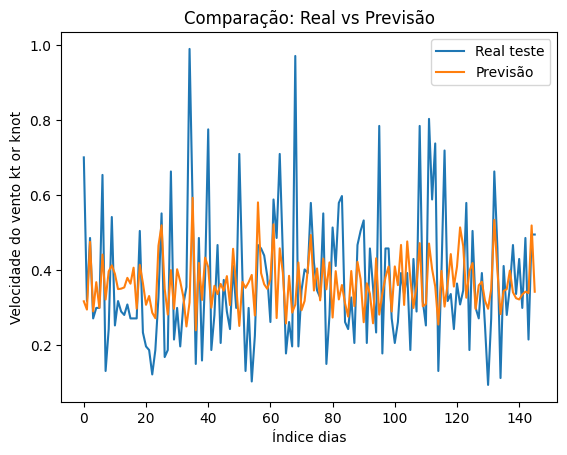

In [198]:
model= Sequential()
 
model.add(LSTM(20,activation='tanh',input_shape=(1,3),recurrent_activation='hard_sigmoid'))
 
model.add(Dense(1))
 
model.compile(loss='mean_squared_error',optimizer='rmsprop',metrics=['mae'])
 
model.fit(X_train,Y_train,epochs= 50,verbose=2)
 
predict= model.predict(X_test)

plt.figure(10)
plt.plot(Y_test, label='Real teste')      
plt.plot(predict, label='Previsão')   
plt.legend()                        
plt.title('Comparação: Real vs Previsão')
plt.xlabel('Índice dias')
plt.ylabel('Velocidade do vento kt or knot')
plt.show()

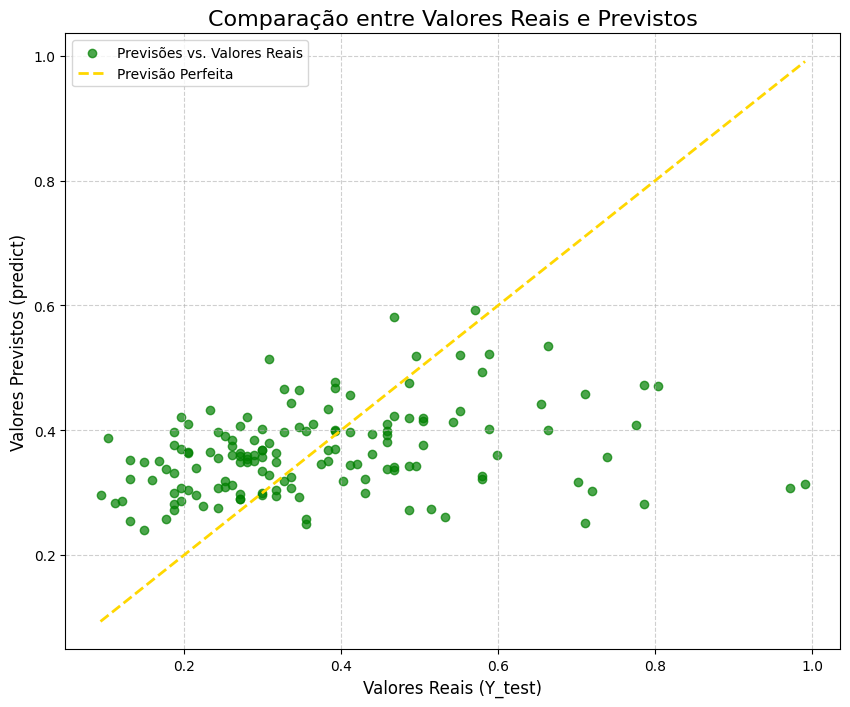

In [199]:
# Cria a figura com um tamanho maior para melhor visualização
plt.figure(figsize=(10, 8))

# Plota os pontos de teste com a cor 'verde'
# Cada ponto representa um par de (Y_test[i], predict[i])
plt.scatter(Y_test, predict, color='green', alpha=0.7, label='Previsões vs. Valores Reais')

# Adiciona a linha de previsão perfeita (Y=X) na cor 'amarelo'
# Esta linha é o que o seu modelo deveria prever se fosse perfeito
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],
         color='gold', linestyle='--', linewidth=2, label='Previsão Perfeita')

# Adiciona títulos e rótulos
plt.title('Comparação entre Valores Reais e Previstos', fontsize=16)
plt.xlabel('Valores Reais (Y_test)', fontsize=12)
plt.ylabel('Valores Previstos (predict)', fontsize=12)

# Adiciona a legenda e uma grade
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()